# 05. When the data cannot answer the question

## 📚 What you will be able to do

By the end of this lesson you can:

1. Take a request written by somebody who is not a data person and decide which of four
   things it is: **answerable**, **answerable once you narrow it**, **answerable but the
   answer would be wrong**, or **not answerable from anything that exists**.
2. Run the check that tells you which one it is, *before* you send a number.
3. Write the reply in three to five sentences of English a manager can act on: what you
   understood the question to be, what the data supports, what it does not, and what you
   propose.
4. Spot the three ways these replies fail — **hedging**, **jargon**, and **burying the
   answer** — in your own writing, not just in somebody else's.

This is not a soft skill with some technical work attached. It is a **technical judgement
with an English artefact attached**, and your instructor marks the two halves separately:
one mark for whether you were right about what the data can carry, one for whether the
reply is usable by the person who asked.

> **About the numbers below.** The 911 table is built from the 25,000-row sample committed
> to this repository, so every student in the room reconciles against the same totals.
> Shares and rankings survive that thinning; raw totals do not, and the notebook says which
> is which every time it matters. The Titanic table is the full 891-row file that ships in
> this repository — and the whole of Request 3 is about what those 891 rows are *not*.

## 🔗 Where this fits

**Assumes** lessons 01–03 of this folder: `SELECT`, `WHERE`, `GROUP BY`, `HAVING`, joins,
and the habit from lesson 03 of proving a number with a control total before you trust it.

**Why this folder exists at all.** It is not one of the twelve official courses of this
diploma. A market pass run for this programme collected 322 real job postings, of which 183
were located in Saudi Arabia and 74 were junior-plausible. SQL was named in 63 of the 183
(34%) and 21 of the 74 (28%) — about four times as often as "deep learning" or "neural
network". The README beside this notebook records that evidence.

**What *this* lesson is for.** The same pass found that 114 of those 183 postings (62%)
ask for stakeholder, presentation or non-technical communication, and that English is named
in 27 of the 74 junior postings (36%) — more often than any technical tool except Python and
SQL. A Riyadh fintech data-analyst posting recorded in that pass asks for the

> "ability to scope a vague business question into something answerable, and to say clearly
> when the data can't answer it."

Lessons 01–03 gave you the first half of that sentence. This lesson is the second half, and
it is the one thing in the posting that **no notebook anywhere else in this diploma
teaches**.

**Feeds into:** every request anybody ever sends you. The four requests below are the four
shapes those requests come in, and after this lesson you should be able to name the shape
before you write a single line of SQL.

## 🎯 The case: 2.38 million answers and the wrong result

In 1936 *The Literary Digest* ran the largest election poll anyone had ever run. It mailed
sample ballots to ten million people. **2.38 million replied** — a response count no
opinion poll before or since has matched. On that mountain of data the *Digest* forecast
that Alf Landon would beat Franklin Roosevelt with **57.08% of the popular vote and 370
electoral votes**.

Roosevelt won **60.8% of the popular vote and 523 electoral votes**, losing only Maine and
Vermont.

The magazine had drawn its names from lists of its own subscribers, of registered
automobile owners and of telephone subscribers — people whose incomes, in the middle of the
Great Depression, were far above the national average — and it had let people decide for
themselves whether to reply. Later work concluded that the second of those was the bigger
problem: people who strongly disliked Roosevelt were the more likely to send their ballot
back.

Hold on to two things from that.

1. **More rows did not help.** 2.38 million responses were wrong in the same direction that
   238 would have been. Volume cannot repair a sample that does not cover the population in
   the question.
2. **No amount of extra analysis inside the file would have found it.** Every number the
   *Digest* computed from its returns was correct. The error lived in the gap between *the
   people in the file* and *the people in the question* — and the only way to see that gap
   is to know how the file was made.

That is what this notebook trains: not a query, but the step before the query.

---

## The four moves

Every reply in this lesson has the same four moves, in this order. Three to five sentences
total. Not four paragraphs — four moves, often two of them inside one sentence.

| # | move | what it does for the reader |
|---|---|---|
| 1 | **Say what you understood the question to be** | lets them stop you in one line if you misread it |
| 2 | **Say what the data supports — the answer, with the number** | this is what they asked for; it goes near the top |
| 3 | **Say what it does not support, and *size* it** | tells them how far they can push the number |
| 4 | **Propose something concrete** | turns "no" into a decision they can make |

Move 4 is the one juniors drop, and it is the one that decides how the reply is received.
"The data cannot answer that" is a dead end. "The data cannot answer that; here is what
would, and I can have it by Wednesday" is a plan.

### The three ways this fails

- **Hedging** — "might", "could potentially", "appears to", "I would want to validate
  further". These words are not banned. *About* 31% is honest; **2.38 million** replies were
  *approximately* 2.38 million. The failure is using them so that no sentence in the reply
  ever commits to anything, which leaves the reader to guess, and they will guess wrong.
- **Jargon** — a word your reader cannot act on. Not "a hard word": `twp` is a short word
  and it is jargon, because it is a column name from a file the reader has never opened.
  If you need a technical term, put its consequence next to it in plain English.
- **Burying** — the answer arrives in the last sentence, after four sentences of caveats.
  Managers read the first line. Some of them read only the first line.

There is a fourth failure that has no name and is worse than all three: **naming a limit
without sizing it.** "There are some missing values" is a worry. "11 of 25,000 calls have no
township, which cannot move any of these five rankings" is information. If you cannot size a
limit, say that too — but say it, do not leave it hanging.

---

## Building the practice database

Two files that already ship with this repository become two SQL tables. Nothing is
installed and nothing is written to your disk: the database lives in RAM and is rebuilt
from scratch every time you run this notebook from the top.

In [1]:
# --- Data setup. Works from any folder, and on Google Colab. -------------------------
# WHY not a relative path: '../../Course 04/datasets/...' only resolves when the kernel's
# working directory happens to be this notebook's folder. This walks up to find the repo.
import pathlib
import re
import sqlite3
import sys

import pandas as pd

_here = pathlib.Path.cwd().resolve()
_root = next((p for p in [_here, *_here.parents] if (p / "tools" / "data.py").exists()), None)
if _root is None:                     # Google Colab, or a stray copy of the notebook
    import urllib.request
    pathlib.Path("tools").mkdir(exist_ok=True)
    try:
        urllib.request.urlretrieve(
            "https://raw.githubusercontent.com/A-Alwabel/"
            "AI-Diploma-Program/main/tools/data.py", "tools/data.py")
    except Exception as _e:
        raise RuntimeError(
            "Could not find the AI Diploma repository from this folder, and could not "
            "download the data loader either. Open this notebook inside a clone of "
            "https://github.com/A-Alwabel/AI-Diploma-Program, or connect to the internet "
            f"and re-run this cell. (underlying error: {_e})") from None
    _root = pathlib.Path.cwd()
sys.path.insert(0, str(_root))

from tools.data import load

print("SQLite engine version :", sqlite3.sqlite_version)

SQLite engine version : 3.52.0


In [2]:
raw = load("montgomery_911_calls", prefer="sample")   # same numbers on every machine
tit = load("titanic")

calls = pd.DataFrame({
    "ts":        raw["timeStamp"],
    "category":  raw["title"].str.split(":").str[0].str.strip(),
    "call_type": raw["title"].str.split(":").str[1].str.strip().str.rstrip("-").str.strip(),
    "twp":       raw["twp"],
    "zip":       raw["zip"].astype("Int64"),   # Int64 (capital I) holds NULLs; plain int cannot
    "addr":      raw["addr"],
    "descr":     raw["desc"],                  # 'desc' is a reserved word in SQL, so: descr
})

con = sqlite3.connect(":memory:")
calls.to_sql("calls", con, index=False)
tit.rename(columns=str.lower).to_sql("passengers", con, index=False)
con.commit()


def q(sql, params=()):
    """Run SQL against the practice database and hand the result back as a DataFrame."""
    return pd.read_sql_query(sql, con, params=params)


def show(sql, note=None, max_rows=30):
    """Run SQL and print the result the way you would read it in a terminal."""
    df = q(sql)
    if note:
        print(note)
    print(df.head(max_rows).to_string(index=False) if len(df) else "(no rows)")
    if len(df) > max_rows:
        print(f"... {len(df) - max_rows} more row(s)")
    print(f"[{len(df):,} row(s)]")
    return df


print("calls      :", q("SELECT COUNT(*) n FROM calls").iloc[0, 0], "rows")
print("passengers :", q("SELECT COUNT(*) n FROM passengers").iloc[0, 0], "rows")

montgomery_911_calls: bundled 25,000-row sample of the 663,522-row original (the full file is on this machine but was not used, because prefer='sample') — every number below is for the sample, not the full file. How it was drawn: 1 row in every 27, evenly spread, so the sample covers the same 2015-12-10 to 2020-07-29 window with all 100 call types and 68 townships.
titanic: full file, 891 rows.
calls      : 25000 rows
passengers : 891 rows


| table | one row is | where it came from |
|---|---|---|
| `calls` | one 911 call | Montgomery County, Pennsylvania emergency call log, 25,000-row committed sample |
| `passengers` | one Titanic passenger | the 891-row Titanic file in `Course 04/datasets/` |

Read the two schemas before you read the requests. Half of this lesson is knowing what is
**not** in a column list.

In [3]:
show("SELECT name, type FROM pragma_table_info('calls')",   note="calls:")
show("SELECT name, type FROM pragma_table_info('passengers')", note="\npassengers:");

calls:
     name    type
       ts    TEXT
 category    TEXT
call_type    TEXT
      twp    TEXT
      zip INTEGER
     addr    TEXT
    descr    TEXT
[7 row(s)]

passengers:
       name    type
passengerid INTEGER
   survived INTEGER
     pclass INTEGER
       name    TEXT
        sex    TEXT
        age    REAL
      sibsp INTEGER
      parch INTEGER
     ticket    TEXT
       fare    REAL
      cabin    TEXT
   embarked    TEXT
[12 row(s)]


---
---

# Request 1 — the one the data can answer

> **From:** Deputy Chief, Operations
> **Subject:** Thursday staffing review
>
> "Before Thursday I need the five townships that generate the most 911 calls, and what
> share of all calls those five account for. One slide."

Read it as a *specification*, not as a mood. It names the unit (township), the measure
(count of calls), the cut (top five), a second quantity (their combined share) and a
deadline. There is nothing vague in it. **Most requests are not like this. When one is,
the professional response is to answer it, in the first sentence, with the number in it.**

Run the analysis far enough to *know* — which here means two queries, not one.

In [4]:
top5 = show("""
SELECT twp,
       COUNT(*)                                                    AS calls,
       ROUND(100.0 * COUNT(*) / (SELECT COUNT(*) FROM calls), 2)   AS pct_of_all_calls
FROM calls
GROUP BY twp
ORDER BY calls DESC
LIMIT 5
""", note="The answer as asked:")

print(f"\nthose five together: {top5['calls'].sum():,} calls, "
      f"{top5['pct_of_all_calls'].sum():.2f}% of all calls")

The answer as asked:
         twp  calls  pct_of_all_calls
LOWER MERION   2102              8.41
    ABINGTON   1520              6.08
  NORRISTOWN   1515              6.06
UPPER MERION   1405              5.62
  CHELTENHAM   1161              4.64
[5 row(s)]

those five together: 7,703 calls, 30.81% of all calls


That is the answer. Before you send it, the second query — the one that turns *"there are
some missing values"* into a sized statement or into silence.

In [5]:
show("""
SELECT COUNT(*)                                            AS rows_total,
       COUNT(DISTINCT twp)                                 AS townships_named,
       SUM(CASE WHEN twp IS NULL THEN 1 ELSE 0 END)        AS rows_with_no_township,
       MIN(ts)                                             AS first_call,
       MAX(ts)                                             AS last_call
FROM calls
""", note="What the file covers:");

What the file covers:
 rows_total  townships_named  rows_with_no_township          first_call           last_call
      25000               68                     11 2015-12-10 18:02:38 2020-07-29 15:52:46
[1 row(s)]


### What you now know

- The five townships and their shares, and that the five together are **30.81%** of the log.
- The log runs **2015-12-10 to 2020-07-29**, names **68 townships**, and has **11 rows out of
  25,000 with no township** — 0.04%. Even if all 11 belonged to a single township they could
  not reorder the five above, whose closest pair (Upper Merion 1,405, Cheltenham 1,161) is 244
  calls apart. That limit is *sized*, and therefore reportable in half a sentence.
- The counts are the sample's counts, one call in twenty-seven. The **shares** are what
  transfers; the raw totals are not the county's totals.

Now the artefact. Here are two replies written from exactly the evidence above.

In [6]:
STRONG = """Yes — the five townships with the most 911 calls are Lower Merion (8.4% of all \
calls), Abington (6.1%), Norristown (6.1%), Upper Merion (5.6%) and Cheltenham (4.6%), and \
together they account for 30.8% of the log. That is measured on the 25,000-call sample of \
the county log covering 10 December 2015 to 29 July 2020, so the shares are solid but the \
raw counts are roughly one twenty-seventh of real volume; use the percentages on the slide, \
not the counts. Two limits worth one line in the meeting: 11 calls out of 25,000 have no \
township recorded, far too few to change any of these five positions, and a call count is \
not a workload, because a fire call and an ambulance call are one row each but not one hour \
each. If workload rather than call volume is what Thursday is really about, I can weight \
these by call category and have it to you Wednesday afternoon."""

WEAK = """Thanks for the question. I have been digging into the call dataset and there are a \
few things to be aware of before we draw any conclusions. The data is a stratified sample of \
the full call log, so the counts are not directly comparable, and there are also NULL values \
in the twp field which could potentially bias the results somewhat. It is also worth noting \
that call volume per township might not be a perfect proxy for staffing requirements. Based \
on a preliminary GROUP BY on twp, Lower Merion appears to be the highest, though I would \
want to validate this further before drawing any firm conclusions."""

for name, text in [("STRONG", STRONG), ("WEAK", WEAK)]:
    print(f"--- {name} " + "-" * 66)
    print(text, "\n")

--- STRONG ------------------------------------------------------------------
Yes — the five townships with the most 911 calls are Lower Merion (8.4% of all calls), Abington (6.1%), Norristown (6.1%), Upper Merion (5.6%) and Cheltenham (4.6%), and together they account for 30.8% of the log. That is measured on the 25,000-call sample of the county log covering 10 December 2015 to 29 July 2020, so the shares are solid but the raw counts are roughly one twenty-seventh of real volume; use the percentages on the slide, not the counts. Two limits worth one line in the meeting: 11 calls out of 25,000 have no township recorded, far too few to change any of these five positions, and a call count is not a workload, because a fire call and an ambulance call are one row each but not one hour each. If workload rather than call volume is what Thursday is really about, I can weight these by call category and have it to you Wednesday afternoon. 

--- WEAK ----------------------------------------------

### Why the weak one is weak

Both replies were written by someone who ran the same two queries and understood them. The
difference is entirely in the delivery, and it is worth naming precisely, because you will
write the weak version by accident.

**It buries the answer.** The only fact the Deputy Chief asked for arrives in the final
sentence — and even then only half of it: *Lower Merion appears to be the highest*. The
other four townships never appear. The 30.8% share, which was the second half of the
request, is never given at all. Four sentences of throat-clearing and caveats come first,
about a number the reader has still not been told. `reply_check` below puts it more bluntly
than that: the weak reply contains **no number anywhere**.

**It hedges.** *A few things to be aware of · could potentially · somewhat · might not be ·
appears to be · would want to validate this further* — eight hedging constructions by the
count in the cell below, and the reply ends by declining to commit to a figure that is, in
fact, certain: Lower Merion is not "appears to be the highest", it is 2,102 calls against
Abington's 1,520, and no amount of further validation is going to close a lead of 582
calls. Hedging is not the same as honesty. Honesty is
*"the shares are solid, the raw counts are not"*. Hedging is refusing to say either.

**It uses jargon, and gets it wrong.** *Stratified sample · NULL values · the twp field ·
GROUP BY · proxy.* The reader does not know that `twp` is a column name — to them it is a
typo. And **"stratified" is the wrong word**: this sample is one row in every twenty-seven,
evenly spread through the file, which is a systematic sample, not a stratified one. That is
what jargon costs you twice over: the reader cannot act on it, and cannot catch you when it
is wrong.

**It names limits without sizing any of them.** "Some NULL values" is 11 rows in 25,000.
The weak reply raises the alarm and gives the reader no way to judge it, so a careful
manager now distrusts the whole slide. The strong reply raises the *same* limit and closes
it in nine words.

Notice one more thing. The strong reply is **longer**. Clarity is not brevity. It is
four moves, in order, with nothing in them that the reader cannot use.

### A tool for your own replies

The next cell defines `reply_check`. Be exact about what it is: **it counts things.** It
cannot tell you whether your reply is true, whether the analysis behind it is right, or
whether what you propose is worth doing — your instructor marks those, separately. What it
can do is catch the three failures above in text you are too close to read properly, which
is every piece of writing five minutes after you write it.

In [7]:
# Words of evasion, not words of uncertainty: "about 31%" is honest and is not on this list.
# What is on it are the constructions that let a sentence avoid committing to anything.
HEDGES = [
    "might", "could potentially", "could be", "may be", "possibly", "perhaps", "maybe",
    "it seems", "i think", "i feel", "sort of", "kind of", "somewhat", "fairly",
    "arguably", "to some extent", "more or less", "hopefully", "i would say",
    "appears to", "would want to", "a few things", "some issues", "not entirely sure",
    "hard to say", "draw any conclusions", "any firm conclusions",
]

# Not "hard words" - words the reader of these replies cannot act on. `twp` is three letters
# and belongs here; "ambulance" is nine and does not.
JARGON = [
    "stratified", "null value", "nulls", "mnar", "missing not at random", "confounder",
    "confounded", "p-value", "statistically significant", "group by", "inner join",
    "left join", "cte", "window function", "dataframe", "schema", "imputation", "imputed",
    "proxy", "granularity", "cardinality", "twp", "pclass", "n/a values", "primary key",
]


def reply_check(text, label="reply"):
    """Count what can be counted in a reply, and say plainly what cannot be."""
    if not text or "TODO" in text:
        print(f"{label}: nothing to check yet — replace the TODO above with your reply.")
        return
    low = " " + " ".join(text.lower().split()) + " "
    sentences = [s for s in re.split(r"(?<=[.!?])\s+", " ".join(text.split())) if s.strip()]
    words = len(text.split())
    # "the first sentence that carries a digit" is the closest mechanical stand-in for
    # "the sentence where the reader finally learns the answer".
    first_num = next((i + 1 for i, s in enumerate(sentences) if re.search(r"\d", s)), None)
    hedges = [h for h in HEDGES if h in low]
    jargon = [j for j in JARGON if re.search(r"\b" + re.escape(j), low)]

    def flag(ok):
        return "ok        " if ok else "look again"

    print(f"{label}")
    print(f"  {flag(3 <= len(sentences) <= 5)} length ........ "
          f"{len(sentences)} sentences, {words} words        [aim: 3-5 sentences]")
    if first_num is None:
        print(f"  {flag(False)} first number .. none anywhere      "
              "[a reply with no number rarely answers anything]")
    else:
        print(f"  {flag(first_num <= 2)} first number .. sentence {first_num} of "
              f"{len(sentences)}         [aim: sentence 1 or 2]")
    print(f"  {flag(not hedges)} hedges ........ "
          f"{', '.join(hedges) if hedges else 'none'}")
    print(f"  {flag(not jargon)} explain or replace  "
          f"{', '.join(jargon) if jargon else 'none'}")
    print("  This cannot check whether your reply is TRUE, whether the analysis behind it")
    print("  is right, or whether what you propose is worth doing. Those are the marks.")


reply_check(STRONG, "STRONG — Request 1")
print()
reply_check(WEAK, "WEAK — Request 1")

STRONG — Request 1
  ok         length ........ 4 sentences, 158 words        [aim: 3-5 sentences]
  ok         first number .. sentence 1 of 4         [aim: sentence 1 or 2]
  ok         hedges ........ none
  ok         explain or replace  none
  This cannot check whether your reply is TRUE, whether the analysis behind it
  is right, or whether what you propose is worth doing. Those are the marks.

WEAK — Request 1
  ok         length ........ 5 sentences, 109 words        [aim: 3-5 sentences]
  look again first number .. none anywhere      [a reply with no number rarely answers anything]
  look again hedges ........ might, could potentially, somewhat, appears to, would want to, a few things, draw any conclusions, any firm conclusions
  look again explain or replace  stratified, null value, group by, proxy, twp
  This cannot check whether your reply is TRUE, whether the analysis behind it
  is right, or whether what you propose is worth doing. Those are the marks.


Read the two reports side by side. The weak reply is *shorter* and scores worse where it
matters: no number anywhere in it, eight hedging constructions, and five terms the Deputy
Chief cannot act on. Note also what the tool got right by accident and what it cannot do —
it passed the weak reply on *length*, because length was never that reply's problem. Then
read the last two lines of each report again. A confident,
clear, well-structured reply that is **wrong** passes every count on that list. The tool is
a spell-checker, not a judge.

---
---

# Request 2 — the one you must narrow first

> **From:** Finance Director
> **Subject:** (no subject)
>
> "Are 911 calls going up? The commissioners will ask on Monday. Give me a number."

Three things in that sentence are undefined, and you cannot answer until you have chosen
one of each — which means **you** are making three decisions the Finance Director thinks she
made:

1. **Up over what period?** Since last year, since 2016, since last month?
2. **Up measured how?** Total calls, calls per resident, calls of one kind?
3. **Which calls?** All 25,000 rows, or the ones that cost the county money?

Do the obvious thing first, so you can see why it is a trap.

In [8]:
show("""
SELECT substr(ts, 1, 4) AS year,
       COUNT(*)         AS calls,
       MIN(ts)          AS first_call,
       MAX(ts)          AS last_call
FROM calls
GROUP BY year
ORDER BY year
""", note="Calls per calendar year, the query everybody writes first:");

Calls per calendar year, the query everybody writes first:
year  calls          first_call           last_call
2015    298 2015-12-10 18:02:38 2015-12-31 23:35:25
2016   5364 2016-01-01 01:03:38 2016-12-31 23:45:47
2017   5287 2017-01-01 01:45:26 2017-12-31 21:57:56
2018   5710 2018-01-01 00:16:55 2018-12-31 23:53:06
2019   5618 2019-01-01 01:50:29 2019-12-31 22:36:34
2020   2723 2020-01-01 00:45:19 2020-07-29 15:52:46
[6 row(s)]


Two numbers in that table are not years.

- **2015** holds 298 calls because the log begins on **10 December 2015**. It is 22 days.
- **2020** holds 2,723 calls because the log ends on **29 July 2020**. It is 211 days.

Read the count column without the two date columns and you get *"calls collapsed by 52% in
2020"*, which is a fact about when somebody stopped exporting the file. This is the single
commonest way a real dashboard lies, and the fix is not clever: **never compare a period to
a period of a different length.**

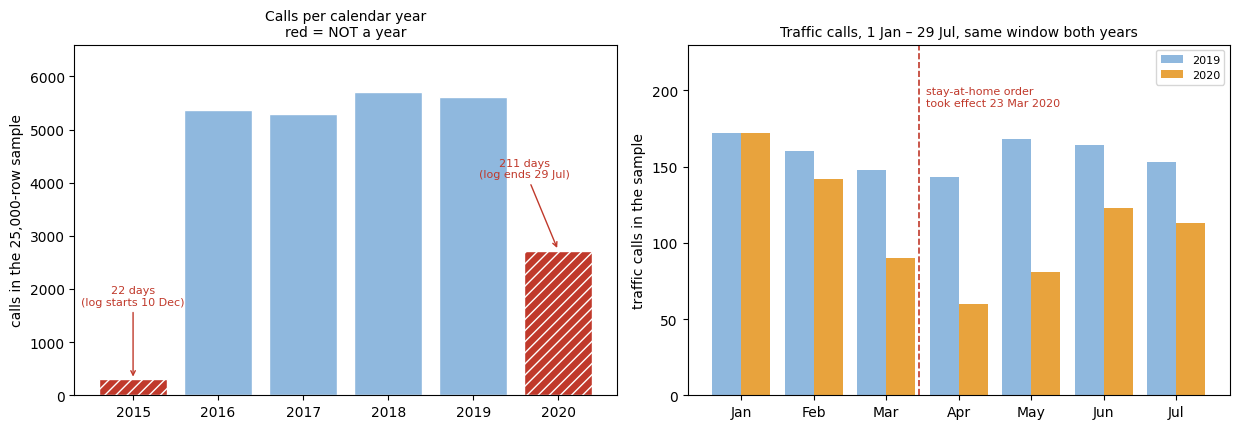

month  y2019  y2020  change_pct
   01    172    172         0.0
   02    160    142       -11.3
   03    148     90       -39.2
   04    143     60       -58.0
   05    168     81       -51.8
   06    164    123       -25.0
   07    153    113       -26.1


In [9]:
import matplotlib.pyplot as plt

per_year = q("""
    SELECT substr(ts, 1, 4) AS year, COUNT(*) AS calls
    FROM calls GROUP BY year ORDER BY year
""")
monthly = q("""
    SELECT substr(ts, 6, 2) AS month,
           SUM(CASE WHEN substr(ts, 1, 4) = '2019' THEN 1 ELSE 0 END) AS y2019,
           SUM(CASE WHEN substr(ts, 1, 4) = '2020' THEN 1 ELSE 0 END) AS y2020
    FROM calls
    WHERE category = 'Traffic' AND substr(ts, 6, 5) <= '07-29'
      AND substr(ts, 1, 4) IN ('2019', '2020')
    GROUP BY month ORDER BY month
""")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4.4))

partial = per_year["year"].isin(["2015", "2020"])
ax1.bar(per_year["year"], per_year["calls"],
        color=["#c0392b" if p else "#8fb8de" for p in partial],
        # hatching, not colour alone: the two red bars must stay distinguishable in print
        hatch=["///" if p else "" for p in partial], edgecolor="white")
ax1.set_title("Calls per calendar year\nred = NOT a year", fontsize=10)
ax1.set_ylabel("calls in the 25,000-row sample")
ax1.annotate("22 days\n(log starts 10 Dec)", xy=(0, 298), xytext=(0, 1700),
             ha="center", fontsize=8, color="#c0392b",
             arrowprops=dict(arrowstyle="->", color="#c0392b"))
ax1.annotate("211 days\n(log ends 29 Jul)", xy=(5, 2723), xytext=(4.6, 4100),
             ha="center", fontsize=8, color="#c0392b",
             arrowprops=dict(arrowstyle="->", color="#c0392b"))
ax1.set_ylim(0, 6600)

x = range(len(monthly))
ax2.bar([i - 0.2 for i in x], monthly["y2019"], width=0.4, color="#8fb8de", label="2019")
ax2.bar([i + 0.2 for i in x], monthly["y2020"], width=0.4, color="#e8a33d", label="2020")
ax2.set_xticks(list(x))
ax2.set_xticklabels(["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul"])
# the line sits at the March/April boundary because the order took effect on 23 March:
# only the last nine days of the March bar are under it, all of April onwards is.
ax2.axvline(2.45, color="#c0392b", lw=1.2, ls="--")
ax2.text(2.55, 190, "stay-at-home order\ntook effect 23 Mar 2020", fontsize=8, color="#c0392b")
ax2.set_title("Traffic calls, 1 Jan – 29 Jul, same window both years", fontsize=10)
ax2.set_ylabel("traffic calls in the sample")
ax2.set_ylim(0, 230)
ax2.legend(fontsize=8)

fig.tight_layout()
plt.show()

print(monthly.assign(change_pct=((monthly["y2020"] / monthly["y2019"] - 1) * 100).round(1))
      .to_string(index=False))

The left panel is the trap. The right panel is what the narrowing buys you: the same
calendar window in both years, so the bars are comparable, and something real underneath —
January is 172 calls against 172, and the gap opens in March.

Now build the honest comparison. Two of them, because "going up" has two defensible
readings and you must pick one and say which.

In [10]:
show("""
SELECT substr(ts, 1, 4) AS year, COUNT(*) AS calls
FROM calls
WHERE substr(ts, 1, 4) BETWEEN '2016' AND '2019'
GROUP BY year ORDER BY year
""", note="Reading A - complete calendar years only (2015 and 2020 dropped):")

show("""
SELECT substr(ts, 1, 4) AS year, COUNT(*) AS calls
FROM calls
WHERE substr(ts, 6, 5) <= '07-29'
GROUP BY year ORDER BY year
""", note="\nReading B - 1 January to 29 July of every year, so 2020 can be included:");

Reading A - complete calendar years only (2015 and 2020 dropped):
year  calls
2016   5364
2017   5287
2018   5710
2019   5618
[4 row(s)]

Reading B - 1 January to 29 July of every year, so 2020 can be included:
year  calls
2016   3063
2017   3004
2018   3274
2019   3224
2020   2723
[5 row(s)]


In [11]:
show("""
SELECT category,
       SUM(CASE WHEN substr(ts, 1, 4) = '2019' THEN 1 ELSE 0 END) AS y2019,
       SUM(CASE WHEN substr(ts, 1, 4) = '2020' THEN 1 ELSE 0 END) AS y2020,
       ROUND(100.0 * SUM(CASE WHEN substr(ts, 1, 4) = '2020' THEN 1 ELSE 0 END)
                   / SUM(CASE WHEN substr(ts, 1, 4) = '2019' THEN 1 ELSE 0 END) - 100, 1)
                                                                  AS change_pct
FROM calls
WHERE substr(ts, 6, 5) <= '07-29' AND substr(ts, 1, 4) IN ('2019', '2020')
GROUP BY category
ORDER BY y2019 DESC
""", note="Reading B, split by what kind of call it was:");

Reading B, split by what kind of call it was:
category  y2019  y2020  change_pct
     EMS   1657   1502        -9.4
 Traffic   1108    781       -29.5
    Fire    459    440        -4.1
[3 row(s)]


### What you now know

- **Reading A, complete years:** 5,364 → 5,287 → 5,710 → 5,618. Year-on-year moves of
  −1.4%, +8.0%, −1.6%. No trend up, no trend down; a band about 8% wide.
- **Reading B, 1 January to 29 July every year:** 3,063 · 3,004 · 3,274 · 3,224 · 2,723.
  2020 is **15.5% below** the same window in 2019 — not the 52% the naive query showed.
- That fall is **not spread evenly**: EMS −9.4%, **Traffic −29.5%**, Fire −4.1%, and inside
  traffic it is a step change, not a slide: January 0.0%, February −11.3%, March −39.2%,
  April −58.0%.
- Montgomery County was placed under a stay-at-home order that took effect on
  **23 March 2020**.

That last bullet is the moment to be careful. The order and the fall in traffic calls line
up, and you did not learn that from this file — you looked it up. **The data shows you a
drop and cannot tell you what caused it.** No column in `calls` records a lockdown, traffic
volume, weather, population or anything else that moved in 2020. If your reply says the
lockdown caused it, you have answered a question the data cannot answer, and you have done
it in the middle of a correct analysis, which is the easiest place in the world to hide one.

### ✍️ Your reply

Write it in the cell below. Three to five sentences, four moves. You are being marked on
two separate things: whether you **narrowed the question correctly and said so**, and
whether the Finance Director can walk into Monday's meeting with your sentence. Decide
which reading you are giving her, say why, and do not give her both without choosing.

In [12]:
reply_2 = """TODO — write your reply to the Finance Director here."""

reply_check(reply_2, "Request 2")

Request 2: nothing to check yet — replace the TODO above with your reply.


---
---

# Request 3 — the one where the data answers, and the answer is wrong

> **From:** Features Editor
> **Subject:** Sunday piece on the Titanic
>
> "For Sunday: what percentage of the people on board the Titanic survived, and were older
> passengers less likely to survive? Two numbers, that is all I need."

You have a Titanic table with a `survived` column and an `age` column. This will take
ninety seconds.

In [13]:
show("""
SELECT COUNT(*)                        AS rows_in_file,
       SUM(survived)                   AS survived,
       ROUND(100.0 * AVG(survived), 1) AS survival_pct
FROM passengers
""", note="Question 1, as asked:")

show("""
SELECT CASE WHEN age < 15 THEN '0-14'  WHEN age < 30 THEN '15-29'
            WHEN age < 45 THEN '30-44' WHEN age < 60 THEN '45-59'
            ELSE '60+' END              AS age_band,
       COUNT(*)                         AS people,
       ROUND(100.0 * AVG(survived), 1)  AS survival_pct
FROM passengers
WHERE age IS NOT NULL
GROUP BY age_band
ORDER BY age_band
""", note="\nQuestion 2, as asked:");

Question 1, as asked:
 rows_in_file  survived  survival_pct
          891       342          38.4
[1 row(s)]

Question 2, as asked:
age_band  people  survival_pct
    0-14      78          57.7
   15-29     306          36.3
   30-44     215          42.3
   45-59      89          40.4
     60+      26          26.9
[5 row(s)]


Two clean numbers. **38.4% survived**, and survival falls from 57.7% among under-15s to
26.9% among the over-60s. Both queries are correct. Both would be defended in a code review.
Send them and the newspaper prints something false.

Three checks stand between you and that. None of them is a harder query — the first one is
not a query at all.

### Check 1 — who is in this file, and who is not?

This is the check that has no SQL. Everything below was looked up, not computed, and it is
the reason the first number is wrong:

- Wikipedia's article on RMS *Titanic* records **"2,208 passengers and crew aboard"** and
  that **"approximately 1,500 died (estimates vary)"**.
- Its article on the crew records that the roughly 1,500 dead included **"approximately 688
  crew members"**.
- The reference passenger dataset that this file descends from — `titanic3`, built by
  Thomas Cason from *Encyclopedia Titanica* — has **1,309 observations**, and its
  documentation states plainly: **"The `TITANIC3` data frame does not contain information
  for the crew."**

So: the file in front of you holds 891 rows. There were about 2,208 people on that ship.
The 1,317-odd people missing from your file are **not a random 60%**. They are the entire
crew — roughly 688 of about 892 died, better than three in four, against 61.6% of the 891
rows you do have — plus the other 418 passengers of the 1,309 in the reference set. The
group you are missing died at a higher rate than the group you kept, which means 38.4% is
not merely the wrong number, it is wrong **upwards**.

`38.4%` is a true statement about 891 rows. It is not the answer to *"what percentage of the
people on board survived"*, and no query written against this table will ever be.

One more thing that makes it worse rather than better: **the sources do not agree with each
other on the denominator.** The same encyclopedia's article on the sinking gives **"892 crew
members and 1,320 passengers"** — 2,212, not 2,208 — while its article on the passengers
opens **"A total of 1,125 people sailed as passengers on the maiden voyage"** and puts the
dead at **"1,496 people, of which around 816 were passengers"**. Three pages, three
denominators. Even the true answer is contested, and a number you cannot pin down is
something the editor needs to know *before* Sunday, not after a correction.

### Check 2 — does the second column cover everybody in the file?

In [14]:
show("""
SELECT COUNT(*)                                                     AS rows_in_file,
       SUM(CASE WHEN age IS NULL THEN 1 ELSE 0 END)                 AS age_missing,
       ROUND(100.0 * AVG(CASE WHEN age IS NULL THEN 1.0 ELSE 0 END), 1) AS pct_missing
FROM passengers
""", note="The age question silently used how many of the 891 rows?");

The age question silently used how many of the 891 rows?
 rows_in_file  age_missing  pct_missing
          891          177         19.9
[1 row(s)]


The age query answered for **714 people, not 891**. You wrote `WHERE age IS NOT NULL`,
which is the responsible thing to write. Here is what the same query does without it.

In [15]:
show("""
SELECT CASE WHEN age < 15 THEN '0-14'  WHEN age < 30 THEN '15-29'
            WHEN age < 45 THEN '30-44' WHEN age < 60 THEN '45-59'
            ELSE '60+' END              AS age_band,
       COUNT(*)                         AS people,
       ROUND(100.0 * AVG(survived), 1)  AS survival_pct
FROM passengers
GROUP BY age_band
ORDER BY age_band
""", note="The same bands, with no WHERE clause at all:");

The same bands, with no WHERE clause at all:
age_band  people  survival_pct
    0-14      78          57.7
   15-29     306          36.3
   30-44     215          42.3
   45-59      89          40.4
     60+     203          29.1
[5 row(s)]


`age < 15` is not true for a passenger with no age — it is `NULL`, which is not true either,
so every one of those `WHEN` tests fails and all **177** of them fall through to `ELSE` and
are reported as **60 and over**. The oldest band goes from 26 people to 203, and its survival
rate from 26.9% to 29.1%, and the story the editor wanted — survival falling with age — comes
out looking exactly the same.

So you have two versions of the truth. With the `WHERE`, a fifth of the file leaves the
analysis and says nothing on the way out. Without it, a fifth of the file is silently filed
as elderly. **Neither output contains a single character that would tell the editor a fifth
of the passengers are unaccounted for.** That is what `NULL` does: it does not raise, it
re-buckets or it disappears.

Either way, it is only a problem if the missing fifth is different from the rest. **Check 3.**

In [16]:
show("""
SELECT CASE WHEN age IS NULL THEN 'age missing' ELSE 'age present' END AS grp,
       COUNT(*)                        AS people,
       ROUND(100.0 * AVG(survived), 1) AS survival_pct
FROM passengers
GROUP BY grp
""", note="Are the dropped rows like the kept rows?")

show("""
SELECT pclass,
       COUNT(*)                                                          AS people,
       SUM(CASE WHEN age IS NULL THEN 1 ELSE 0 END)                      AS age_missing,
       ROUND(100.0 * AVG(CASE WHEN age IS NULL THEN 1.0 ELSE 0 END), 1)  AS pct_missing,
       ROUND(100.0 * AVG(survived), 1)                                   AS survival_pct
FROM passengers
GROUP BY pclass
ORDER BY pclass
""", note="\nAnd where do the missing ages sit?");

Are the dropped rows like the kept rows?
        grp  people  survival_pct
age missing     177          29.4
age present     714          40.6
[2 row(s)]

And where do the missing ages sit?
 pclass  people  age_missing  pct_missing  survival_pct
      1     216           30         13.9          63.0
      2     184           11          6.0          47.3
      3     491          136         27.7          24.2
[3 row(s)]


### What you now know

- The dropped rows are **not** like the kept rows: **29.4%** of the passengers with no age
  survived, against **40.6%** of those with an age. The age analysis threw away the people
  who died at the higher rate.
- The missing ages are **not spread evenly by class** either: 27.7% of third class have no
  age, against 6.0% of second class. Third class is also the class that died most (24.2%
  survived, against 63.0% in first). So the age table over-represents the classes that
  survived, twice over.
- And the ages that *are* there are not all measurements. The `titanic3` documentation says
  it contains **"actual and estimated ages for almost 80% of the passengers"** — this file
  is 80.1% covered, which lines up, and it means some of the numbers in your age bands were
  inferred by a historian, not read off a ticket.

Nothing here says the age pattern is false. Children really may have survived at a higher
rate. What it says is that **this file cannot establish it**, because the rows it is missing
are missing for reasons connected to the very thing being measured.

### ✍️ Your reply

The editor asked for two numbers and has a Sunday deadline. You are going to give her
neither of them as asked. Say what you *can* give her — there is something real here, and a
reply that offers nothing is a failed reply. You are marked on whether you identified the
right reason each number fails (they fail for **different** reasons), and on whether the
editor, who is not a data person and is in a hurry, can act on your sentences.

In [17]:
reply_3 = """TODO — write your reply to the Features Editor here."""

reply_check(reply_3, "Request 3")

Request 3: nothing to check yet — replace the TODO above with your reply.


---
---

# Request 4 — the one that needs data nobody collected

> **From:** Deputy Chief, Operations
> **Subject:** commissioners' question
>
> "The commissioners want to know whether our average response time has improved since
> 2018. It is all in the call log, isn't it? Pull it out."

Start where the honest answer starts: ask the database.

In [18]:
q("SELECT AVG(response_time) FROM calls")

DatabaseError: Execution failed on sql 'SELECT AVG(response_time) FROM calls': no such column: response_time

`no such column: response_time`. That took two seconds and it is worth more than an hour of
searching, because the error is the finding. But do not stop there — "the column is not
called that" is not the same as "the data is not there", and a manager will rightly ask
whether you looked properly.

In [19]:
show("SELECT name, type FROM pragma_table_info('calls')",
     note="Every column there is. Read it as a list of what the county recorded:")

show("SELECT ts, category, call_type, addr FROM calls ORDER BY ts LIMIT 3",
     note="\nOne row, in full - what does a row actually record?");

Every column there is. Read it as a list of what the county recorded:
     name    type
       ts    TEXT
 category    TEXT
call_type    TEXT
      twp    TEXT
      zip INTEGER
     addr    TEXT
    descr    TEXT
[7 row(s)]

One row, in full - what does a row actually record?
                 ts category        call_type                                 addr
2015-12-10 18:02:38      EMS      HEAD INJURY PENLLYN BLUE BELL PIKE & VILLAGE CIR
2015-12-10 19:08:43  Traffic ROAD OBSTRUCTION      W MT VERNON ST & S MITCHELL AVE
2015-12-10 20:36:49  Traffic VEHICLE ACCIDENT             BELMONT AVE & E CITY AVE
[3 row(s)]


One row is **the moment a call was received**, its type, and where it came from. There is no
second timestamp anywhere in the table — no dispatch time, no arrival time, no time the
incident closed. A response time is a *difference between two events*, and this file records
one event.

That is not a gap you can query around. But there is something in here that will tempt you,
and the tempting thing is why this request is dangerous rather than merely impossible.

In [20]:
show("""
SELECT COUNT(*)                                                        AS rows_total,
       SUM(CASE WHEN descr LIKE '%Station%' THEN 1 ELSE 0 END)         AS mentions_a_station,
       ROUND(100.0 * AVG(CASE WHEN descr LIKE '%Station%' THEN 1.0 ELSE 0 END), 1)
                                                                       AS pct
FROM calls
""", note="The free-text description column:")

show("SELECT descr FROM calls ORDER BY ts LIMIT 4",
     note="\nWhat that text looks like:");

The free-text description column:
 rows_total  mentions_a_station  pct
      25000               16356 65.4
[1 row(s)]

What that text looks like:
                                                                               descr
PENLLYN BLUE BELL PIKE & VILLAGE CIR;  WHITPAIN; Station 385; 2015-12-10 @ 18:02:38;
                   W MT VERNON ST & S MITCHELL AVE; LANSDALE; 2015-12-10 @ 19:08:43;
                      BELMONT AVE & E CITY AVE; LOWER MERION; 2015-12-10 @ 20:36:49;
        HEATH RD & ZOLLINGER WAY; LOWER MERION; 2015-12-10 @ 23:01:58-Station:STA26;
[4 row(s)]


### What you now know

- **65.4%** of rows mention a station in a free-text field, in at least two different
  formats (`Station 385` and `-Station:STA26`), and 34.6% mention none at all.
- A station is **who was sent**, not **when they arrived**. Parsing that field carefully out
  of two-thirds of the rows would produce a real, clean, well-tested number that answers a
  different question from the one the Deputy Chief asked. Spending three days on it and
  presenting it as a response time would be the worst outcome available in this notebook,
  and it is the outcome a keen junior analyst reaches by working hard.
- To answer the question as asked you need records this file does not contain and nothing
  in the repository contains either: **time call received** (you have this), **time a unit
  was dispatched**, **time the unit arrived on scene**, a **unit identifier**, and an
  **incident number** to join those events to this row. Those live in a Computer-Aided
  Dispatch system, not in a call log export.
- And "since 2018" needs the same records for 2018, which means the question is not only
  about collecting data from now on — it is about whether the old records were kept.

### ✍️ Your reply

This is the reply where **move 4 is the entire value of the message**. Anyone can write "we
do not have that". You are marked on whether you named the specific fields that would be
needed, whether you distinguished what you *do* have from what you do not, and whether the
Deputy Chief could forward your message to whoever owns the dispatch system without
rewriting it. Do not promise a number you cannot produce, and do not offer the station field
as a substitute without saying exactly what it would and would not measure.

In [21]:
reply_4 = """TODO — write your reply to the Deputy Chief here."""

reply_check(reply_4, "Request 4")

Request 4: nothing to check yet — replace the TODO above with your reply.


---

## The phrase bank

You are writing these in English to somebody senior, and the hard part is not the grammar —
it is finding a construction that is direct without being blunt. These are the frames that
do that work. Use them until you do not need them.

**Move 1 — say what you understood the question to be**

- "You asked for X, for Y, by Z."
- "As I read it, the question is X. If you meant something else, tell me before Thursday."
- "Short answer first, then two limits."

**Move 2 — say what the data supports**

- "Yes — and here is the number: …"
- "The log supports this much: …"
- "I can state X with confidence. Here it is."

**Move 3 — say what it does not support, and size it**

- "What this number does not cover is …"
- "It cannot tell you X, because the file records A, not B."
- "The log stops on 29 July 2020, so any comparison with a full year is not like for like."
- "11 rows of 25,000 have no township — too few to move any of these five positions."
- "I can give you the share. I cannot give you the county total, because …"

**Move 4 — propose**

- "What I propose is …"
- "If X is what you actually need, the way to get it is Y, and I would need Z."
- "The cheapest next step is …"
- "I can have that with you by Wednesday afternoon."

**Two things never to write**

- *"Let me know if you have any questions"* as your only proposal. It moves the work back
  to the person who already told you what they wanted.
- *"The data is not good enough"* without saying what would be good enough. That sentence
  costs you the request and teaches the reader nothing, and next time they will ask someone
  who says yes.

---

## 💬 Discuss

No single right answer to any of these. Take a side and defend it out loud.

1. **Request 2 has two defensible readings and you had to pick one.** Reading A says calls
   are flat; Reading B says they fell 15.5%. Both are true. If you give the Finance Director
   only one, you have made her decision for her; if you give her both, she picks the one she
   already believed. What do you actually send, and does your answer change if you know
   which one she is hoping for?

2. **The stay-at-home order.** You looked it up; it is not in the file. Is putting it in the
   reply good practice — the context the number needs — or is it smuggling in a cause the
   data cannot support? Where exactly is the line, and how would you write the sentence so
   it stays on the right side of it?

3. **Request 3, in a hurry.** The editor is on deadline and will print *something*. Is a
   reply that gives her the correct passenger-only number, clearly labelled, better or worse
   than one that declines both numbers? What is the worst thing that happens with each?

4. **Request 4's station field.** A colleague spends two days parsing it and produces "calls
   per station per year". It is careful work and it is not a response time. Do you put it in
   front of the commissioners? What do you owe your colleague, and what do you owe the
   commissioners, and which wins?

5. **Saying no is not free, and it is not equally cheap for everyone.** A junior person, in
   their second language, telling a director that the question cannot be answered is not
   doing the same act as a director saying it. What in the four moves reduces that cost, and
   what would you want your manager to do so that this becomes safe to do twice?

6. **Which of the four moves would you keep** if you were allowed only one sentence?

---

## ⚠️ Where this breaks

**The four moves do not tell you whether the data can answer the question.** They are the
shape of the reply, not the judgement inside it. Nothing in this notebook — and nothing in
SQL — would have told you that the Titanic file contains no crew. You had to know how the
file was made. **The moves are only as good as the check that precedes them, and that check
is knowledge, not technique.** When you meet a new table, the first question is never "what
is in it" but "who made this, from what, and who is missing".

**`reply_check` counts words.** A clear, confident, well-structured, completely wrong reply
scores clean on every line it prints. It says so itself, in its last two lines, and you
should read those every time.

**Declining is also a failure mode, and it is invisible.** Everything above trains you to
say no. Saying no when the answer was in fact available costs your employer a decision and
costs you your reputation, and nobody ever audits the analyses that were never done. There
is no query for this one. The only defence is move 4: if you decline, you must be able to
say precisely what would change your mind.

**"The data cannot answer that" can be turned around and used against you.** On the night of
27 January 1986, Morton Thiokol engineers recommended against launching *Challenger* until
the temperature was above 53 °F, on the grounds that they had no data at colder temperatures
than any previous launch. Their own management reversed the recommendation, stating that the
evidence on the O-rings **"was inconclusive"**. The same absence of data was read one way by
the people who wanted to say stop and the other way by the people who wanted to go. If your
argument is "we do not know", expect it to come back as "so there is no reason not to". The
defence is again move 4 — say what you would need, say what you would do in the meantime,
and put it in writing so that the record exists whatever gets decided.

**These are sample numbers.** Every 911 figure above is from the 25,000-row committed
sample, one call in twenty-seven. The shares transfer and the totals do not. Checked against
the full 663,522-row file, which is not committed to this repository: the like-for-like
2020-versus-2019 fall is −15.6% there against −15.5% here, and the traffic component is
−32.9% there against −29.5% here. Same story, different second digit — which is exactly the
level of agreement you should expect from a sample, and exactly why the strong reply in
Request 1 put the percentages on the slide and left the counts off it.

**The politics are real and this notebook cannot fix them.** Some managers do not want the
honest answer, and some organisations punish the person who gives it. The four moves make
the reply hard to argue with; they do not make it welcome. What they *do* give you is an
artefact — a written record, sent, with a date on it, that says what you knew and when you
knew it. On a bad day that is the only thing between you and the consequences of somebody
else's decision.

## The card to keep

Before you answer any request:

1. **Which of the four shapes is this?** Answerable · answerable once narrowed · answerable
   but wrong · not in any data that exists.
2. **Who is missing from the file?** Not what is in it — who is *not*, and are they missing
   for a reason connected to the question.
3. **Does every column cover every row?** `COUNT(*)` against `COUNT(column)`. If not, are
   the missing rows like the rest?
4. **Is any period a different length from any other period?** Compare the `MIN` and `MAX`,
   never just the counts.
5. **What is the smallest true thing I can send?** Then send that, in sentence one.

And the reply, always in this order: **what you understood · what it supports · what it does
not, sized · what you propose.** Three to five sentences. The number goes near the top.

## References

Each of these is used above, not decoration.

- Wikipedia, *The Literary Digest* — the 1936 poll: ten million ballots mailed, 2.38 million
  returned, Landon forecast at 57.08% and 370 electoral votes, Roosevelt's actual 60.8% and
  523, and the sampling-frame and non-response explanations (Squire 1988; Lusinchi).
  <https://en.wikipedia.org/wiki/The_Literary_Digest>
- Wikipedia, *RMS Titanic* — "2,208 passengers and crew aboard", "approximately 1,500 died
  (estimates vary)". <https://en.wikipedia.org/wiki/RMS_Titanic>
- Wikipedia, *Sinking of the Titanic* — "892 crew members and 1,320 passengers", the
  competing total quoted in Check 1.
  <https://en.wikipedia.org/wiki/Sinking_of_the_Titanic>
- Wikipedia, *Crew of the Titanic* — "approximately 688 crew members" among the dead.
  <https://en.wikipedia.org/wiki/Crew_of_the_Titanic>
- Wikipedia, *Passengers of the Titanic* — "A total of 1,125 people sailed as passengers on
  the maiden voyage" and "the deaths of 1,496 people, of which around 816 were passengers";
  the third denominator quoted in Check 1.
  <https://en.wikipedia.org/wiki/Passengers_of_the_Titanic>
- `TITANIC3` reference documentation (PASWR2 package, after Thomas Cason's build from
  *Encyclopedia Titanica*) — 1,309 observations, "does not contain information for the
  crew", "actual and estimated ages for almost 80% of the passengers"; the origin of the
  file used here. <https://alanarnholt.github.io/PASWR2/reference/TITANIC3.html> and
  <https://hbiostat.org/data/repo/titanic.html>
- Littler, *Pennsylvania Issues Stay at Home Order Covering Numerous Counties* — the order
  covering Montgomery County "took effect on March 23, 2020 at 8:00 EDT", the date marked on
  the right-hand panel of the figure.
  <https://www.littler.com/news-analysis/asap/pennsylvania-issues-stay-home-order-covering-numerous-counties>
- Wikipedia, *Space Shuttle Challenger disaster* — the recommendation against launching
  "until the temperature was above 53 °F (12 °C)" and the reversal on the grounds that the
  O-ring evidence "was inconclusive", quoted in "Where this breaks".
  <https://en.wikipedia.org/wiki/Space_Shuttle_Challenger_disaster>
- Data sources: the Montgomery County (PA) 911 call log and the 891-row Titanic passenger
  file, both described in `Course 04/datasets/DATA.md`.